<a id="top"></a>
<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>APRENDIZADO DE MÁQUINA (CIC1205/GCC1932) - Trabalho 1</center></h1>

- Nome completo: Hélio Henrique de Souza
- [Link para vídeo](<LINK_VIDEO>)
- [Link para git](<https://github.com/HezaH/Machine_Learning>)

# Import Libs

In [73]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import (
    train_test_split, KFold, RandomizedSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score,
    confusion_matrix, brier_score_loss, mean_squared_error, mean_absolute_error, r2_score,
    classification_report
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV, CalibrationDisplay
from imblearn.pipeline import Pipeline as ImPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss, ClusterCentroids, TomekLinks
)
from imblearn.combine import SMOTEENN, SMOTETomek
from scipy.stats import randint, uniform
from math import sqrt
import pickle
import json


# Main functions

In [ ]:
def plot_confusion_matrix_from_values(tp, tn, fp, fn, labels=['Negativo', 'Positivo'], title='Matriz de Confusão'):
    """
    Plota a matriz de confusão a partir dos valores TP, TN, FP, FN.

    Parâmetros:
    - tp: Verdadeiros Positivos
    - tn: Verdadeiros Negativos
    - fp: Falsos Positivos
    - fn: Falsos Negativos
    - labels: Lista com os rótulos das classes [Negativo, Positivo]
    - title: Título do gráfico
    """
    cm = np.array([[tn, fp],
                   [fn, tp]])

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Classe Predita')
    plt.ylabel('Classe Real')
    plt.title(title)
    plt.show()

def plot_calibration_curve(y_test, y_prob, plot_title, method_label="", n_bins=15):
    disp = CalibrationDisplay.from_predictions(y_test, 
                                               y_prob, 
                                               n_bins=n_bins,
                                               color='red',  
                                               marker='o',  
                                               markersize=4,  
                                               markeredgecolor='red',  
                                               markerfacecolor='red', 
                                               label=method_label,  
                                               )

    disp.ax_.set_title(plot_title)

    plt.grid(True)
    plt.show()

def add_calibration_curve(ax, y_true, y_prob, n_bins=15, label=""):
    # Generate calibration display from predictions and true labels
    disp = CalibrationDisplay.from_predictions(y_true, y_prob, n_bins=n_bins, ax=ax, label=label)
    return disp


def compute_brier_score(y_true, y_prob):
    """Calculate the Brier Score."""
    return brier_score_loss(y_true, y_prob)

def compute_ece(y_true, y_prob, n_bins=10):
    """Calculate the Expected Calibration Error (ECE)."""
    y_true = np.asarray(y_true)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    total = len(y_prob)
    ece = 0.0
    for i in range(n_bins):
        indices = np.where(binids == i)[0]
        if len(indices) == 0:
            continue
        avg_prob = np.mean(y_prob[indices])
        avg_true = np.mean(y_true[indices])
        weight = len(indices) / total
        ece += weight * np.abs(avg_prob - avg_true)
    return ece

def compute_mce(y_true, y_prob, n_bins=10):
    """Calculate the Maximum Calibration Error (MCE)."""
    y_true = np.asarray(y_true)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    mce = 0.0
    for i in range(n_bins):
        indices = np.where(binids == i)[0]
        if len(indices) == 0:
            continue
        avg_prob = np.mean(y_prob[indices])
        avg_true = np.mean(y_true[indices])
        error = np.abs(avg_prob - avg_true)
        if error > mce:
            mce = error
    return mce

def evaluate_calibration(y_true, y_prob, n_bins=10):
    """
    Calculate calibration metrics: Brier Score, ECE, and MCE.
    Returns a dictionary with these metrics.
    """
    brier = compute_brier_score(y_true, y_prob)
    ece   = compute_ece(y_true, y_prob, n_bins=n_bins)
    mce   = compute_mce(y_true, y_prob, n_bins=n_bins)
    return {"Brier Score": brier, "ECE": ece, "MCE": mce}

def select_best_calibration(result_list):
    """
    Select the best calibration configuration based on
    (Brier Score + ECE). Returns the corresponding dictionary.
    """
    best_config = None
    best_score = float('inf')
    for res in result_list:
        score = res["Brier Score"] + res["ECE"]
        if score < best_score:
            best_score = score
            best_config = res
    return best_config


def plot_results(phase, result):
    # Configurações gerais
    plt.figure(figsize=(12, 5))
    sns.set_theme(style="whitegrid")
    
    # Plot 1: Matriz de Confusão
    plt.subplot(1, 2, 1)
    cm = result["Confusion_Matrix"]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Pred 0', 'Pred 1'], 
                yticklabels=['True 0', 'True 1'])
    plt.title(f'Matriz de Confusão ({phase})')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Previsto')
    
    # Plot 2: Métricas de Classificação
    plt.subplot(1, 2, 2)
    report = result["Classification_Report"]
    metrics = ['precision', 'recall', 'f1-score']
    classes = ['0', '1', 'accuracy']
    scores = []
    for cls in classes:
        if cls in report:
            if cls == 'accuracy':
                scores.append(report[cls])
            else:
                scores.extend([report[cls][metric] for metric in metrics])
    
    # Ajuste para incluir 'accuracy'
    labels = []
    for cls in ['0', '1']:
        for metric in metrics:
            labels.append(f"{cls} {metric}")
    labels.append('accuracy')
    
    sns.barplot(x=labels, y=scores, palette="viridis")
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Métricas ({phase})')
    plt.ylim(0, 1)
    plt.tight_layout()
    
    plt.show()
    # Para salvar a figura em vez de mostrar:
    plt.savefig(f'resultados_{phase}.png')
    plt.close()

def report_severity_metrics(y_true, y_pred):
    """
    Calcula e retorna as métricas para cada nível de severidade da precipitação.
    
    Severidade:
      - sem_chuva_leve: 0 <= x < 5
      - moderada: 5 <= x < 25
      - forte: 25 <= x < 50
      - tempestade: x >= 50
    """
    # Converter as entradas para arrays 1D (unidimensionais)
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    
    severity_levels = {
        "sem_chuva_leve": (0, 5),
        "moderada": (5, 25),
        "forte": (25, 50),
        "tempestade": (50, np.inf)
    }
    report = {}
    for level, (low, high) in severity_levels.items():
        mask = (y_true >= low) & (y_true < high)
        count = np.sum(mask)
        if count > 0:
            mse = mean_squared_error(y_true[mask], y_pred[mask])
            mae = mean_absolute_error(y_true[mask], y_pred[mask])
            rmse = np.sqrt(mse)
            r2 = r2_score(y_true[mask], y_pred[mask])
            report[level] = {"count": int(count), "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
        else:
            report[level] = {"count": 0, "MAE": None, "MSE": None, "RMSE": None, "R2": None}
    return report

def plot_severity_metrics(severity_report, model_name):
    """Plota métricas por nível de severidade"""
    levels = list(severity_report.keys())
    metrics = ['MAE', 'RMSE', 'R2']
    
    plt.figure(figsize=(15, 5))
    for i, metric in enumerate(metrics, 1):
        plt.subplot(1, 3, i)
        values = [severity_report[level][metric] for level in levels]
        sns.barplot(x=levels, y=values, palette='viridis')
        plt.title(metric)
        plt.xticks(rotation=45)
        plt.ylabel(metric)
    
    plt.suptitle(f'Métricas por Severidade - {model_name}')
    plt.tight_layout()
    plt.show()
    plt.savefig(f'severity_metrics_{model_name}.png')
    plt.close()

def model_evaluation_regression(model_name, y_test, y_pred):
    """
    Avalia o desempenho de um modelo de regressão:
      - Exibe um gráfico com: 
            (1) Previsões vs. Valores reais
            (2) Gráfico dos resíduos
      - Exibe num texto as métricas MSE e R²

    Parameters:
      y_test : array-like, valores reais
      y_pred : array-like, valores previstos pelo modelo    
    """
    # Calcula as métricas
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    residuals = y_test - y_pred

    # Cria um figure com 2 subplots lado a lado
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Predicted vs Actual
    axs[0].scatter(y_test, y_pred, color='blue', alpha=0.6)
    axs[0].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()],
                'r--', lw=2)
    axs[0].set_xlabel("Actual")
    axs[0].set_ylabel("Predicted")
    axs[0].set_title("Predicted vs Actual")
    axs[0].grid(True)

    # 2. Residuals Plot
    axs[1].scatter(y_pred, residuals, color='green', alpha=0.6)
    axs[1].axhline(0, color='red', linestyle='--', lw=2)
    axs[1].set_xlabel("Predicted")
    axs[1].set_ylabel("Residuals")
    axs[1].set_title("Residual Plot")
    axs[1].grid(True)

    # Adiciona as métricas no figure (por exemplo, na parte inferior central)
    metrics_text = f"MSE: {mse:.2f}\nR²: {r2:.2f}"
    plt.figtext(0.5, 0.01, metrics_text, wrap=True, horizontalalignment='center', fontsize=12)

    # Ajusta o layout para não sobrepor a área das métricas
    plt.show()
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(f'{model_name}.png')

def model_evaluation(model_name, y_true, y_pred, feature_importances=None):
    """Gera visualizações completas de avaliação do modelo"""
    plt.figure(figsize=(15, 6))
    
    # Gráfico 1: Valores Reais vs. Previstos
    plt.subplot(1, 3, 1)
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.title('Valores Reais vs. Previstos')
    plt.xlabel('Real')
    plt.ylabel('Previsto')
    
    # Gráfico 2: Distribuição dos Resíduos
    plt.subplot(1, 3, 2)
    residuals = y_true - y_pred
    sns.histplot(residuals, kde=True)
    plt.title('Distribuição dos Resíduos')
    plt.xlabel('Resíduo')
    
    # Gráfico 3: Feature Importance (apenas para Gradient Boosting)
    if feature_importances is not None:
        plt.subplot(1, 3, 3)
        indices = np.argsort(feature_importances)[::-1]
        features = feature_names if 'feature_names' in globals() else indices
        plt.barh(range(len(indices)), feature_importances[indices], align='center')
        plt.yticks(range(len(indices)), [features[i] for i in indices])
        plt.title('Importância das Features')
    
    plt.tight_layout()
    plt.savefig(f'{model_name}_evaluation.png')
    plt.close()

# (1) Predição de pagamento de empréstimos

Importando o modelo, definindo as colunas 

In [91]:
# Inicia a medição do tempo
start_time = time.time()
# ===========================
# CARREGAMENTO E PRÉ-PROCESSAMENTO
# ===========================
# Definição das colunas
name_columns = ["ESCT", "NDEP", "RENDA", "TIPOR", "VBEM", "NPARC", "VPARC", "TEL", "IDADE", "RESMS", "ENTRADA", "CLASSE"]
cat_columns = ["ESCT", "NDEP", "TIPOR", "TEL"]  # OBS.: 'TIPOR' e 'TEL' já vem com valores 0 e 1
num_columns = ["RENDA", "VBEM", "NPARC", "VPARC", "IDADE", "RESMS", "ENTRADA"]
target_column = "CLASSE"  # 1 se o cliente pagou a dívida

# Carregamento dos dados de treino e teste
try:
    df_train = pd.read_csv('credtrain.txt', sep='\t', header=None)
    df_test = pd.read_csv('credtest.txt', sep='\t', header=None)
except FileNotFoundError:
    path_base = os.path.dirname(os.path.realpath(__file__))
    df_train = pd.read_csv(os.path.join(path_base, 'credtrain.txt'), sep='\t', header=None)
    df_test = pd.read_csv(os.path.join(path_base, 'credtest.txt'), sep='\t', header=None)


Ajustando e definindo a base de dados para teste e treino

In [92]:
df_train.columns = name_columns
df_test.columns = name_columns

# Separação entre features e target
X_test, y_test = df_test.drop(target_column, axis=1), df_test[target_column]
X_train, y_train = df_train.drop(target_column, axis=1), df_train[target_column]

# Divisão adicional: treino e validação
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, train_size=.5)
df_train_split = pd.DataFrame(X_train_split, columns=name_columns[:-1])
df_train_split[target_column] = y_train_split

df_val = pd.DataFrame(X_val, columns=name_columns[:-1])
df_val[target_column] = y_val


Pré processamento e definição dos modelos

In [93]:
# Criação do pré-processador utilizando ColumnTransformer:
# - OneHotEncoder para as colunas categóricas.
# - StandardScaler para as colunas numéricas.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_columns),
        ('num', StandardScaler(), num_columns)
    ]
)

# Ajuste do pré-processador com os dados de treino (apenas as features) e aplicação nas partições
X_train_split_transformed = preprocessor.fit_transform(X_train_split)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

# Define model configurations; include tuning keys for models that require parameter tuning.
model_configurations = [
    {
        'class_name': "KNeighborsClassifier",
        'model_class': KNeighborsClassifier
    },
    {
        'class_name': "LogisticRegression",
        'model_class': LogisticRegression
    },
    {
        'class_name': "GradientBoostingClassifier",
        'model_class': GradientBoostingClassifier,
    }
]


Loop para iteirar sobre qual o melhor modelo dentro os parametros informados, usando o fit e o tarnsform para realizar as predições

Processando modelo: KNeighborsClassifier
Best threshold (Val) for KNeighborsClassifier': 0.6000 | Young: 0.6856
Best threshold (Test) for KNeighborsClassifier': 0.8000 | Young: 0.7336


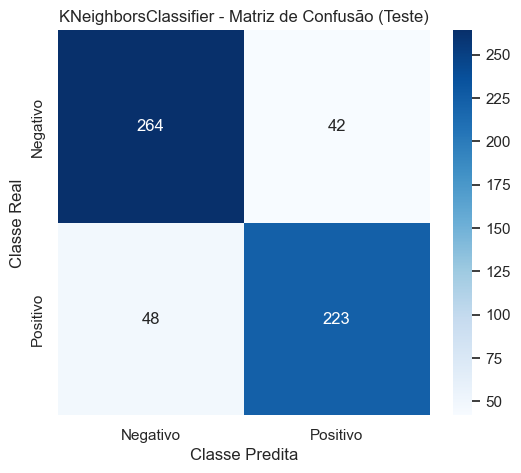

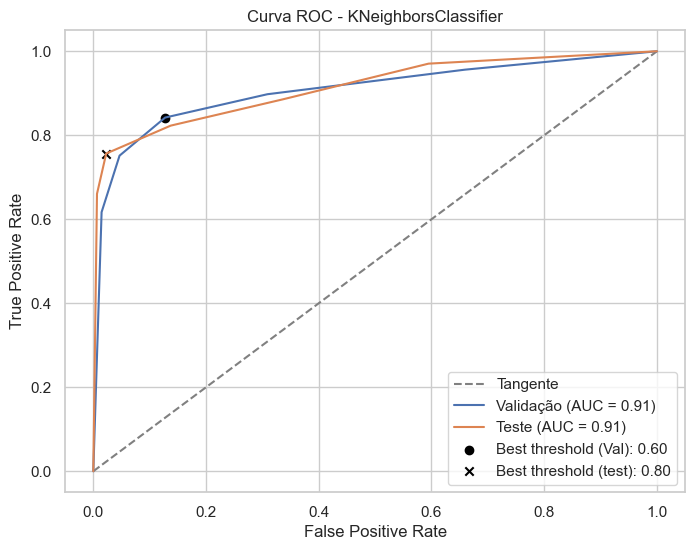

Processando modelo: LogisticRegression
Best threshold (Val) for LogisticRegression': 0.6431 | Young: 0.7346
Best threshold (Test) for LogisticRegression': 0.6628 | Young: 0.7561


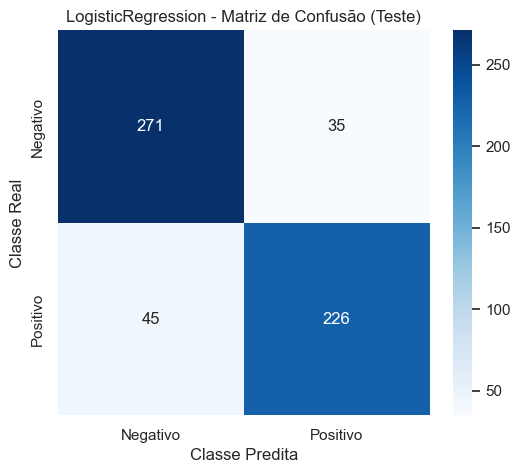

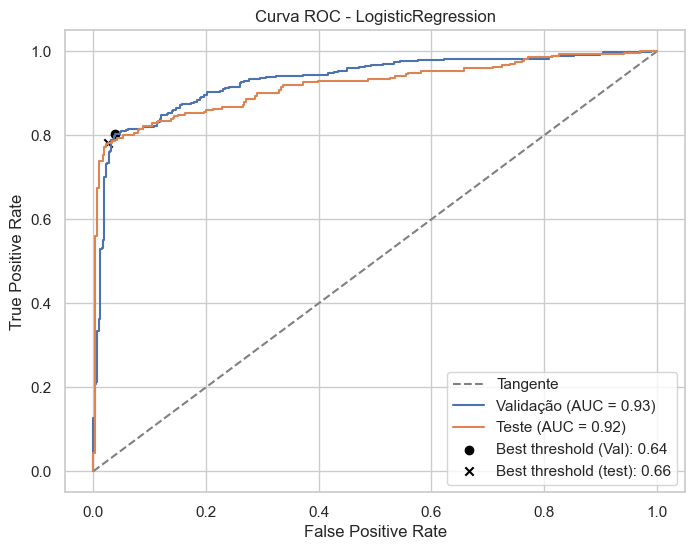

Processando modelo: GradientBoostingClassifier
Best threshold (Val) for GradientBoostingClassifier': 0.6684 | Young: 0.7547
Best threshold (Test) for GradientBoostingClassifier': 0.6438 | Young: 0.7726


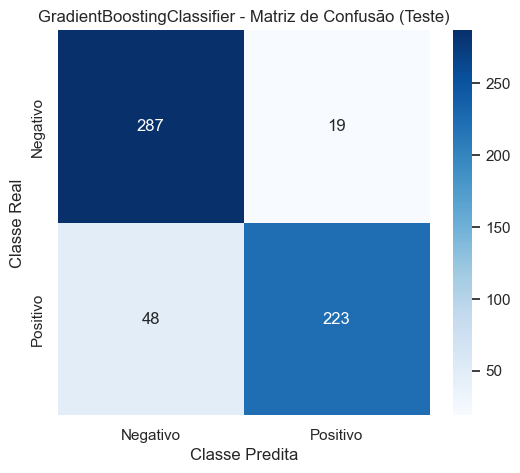

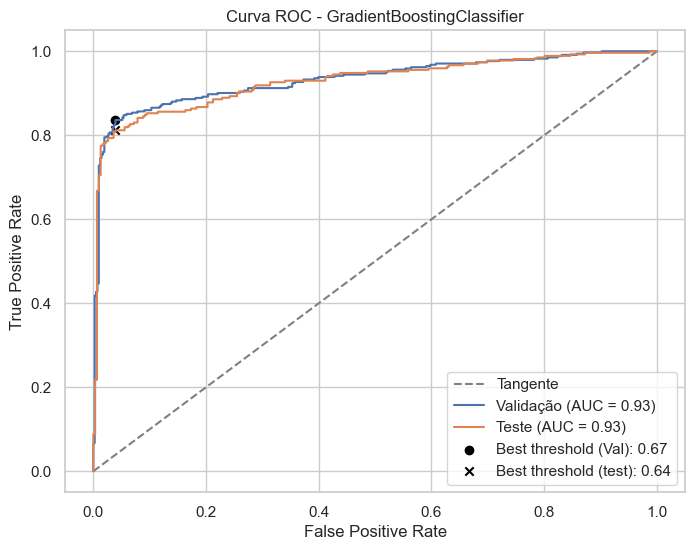

In [94]:
# Lista para armazenar os resultados
results = []

# Loop pelos modelos
for config in model_configurations:
    model_class_name = config['class_name']
    print(f"Processando modelo: {model_class_name}")
    
    # Instanciar o modelo com os parâmetros default e criar o pipeline
    clf = config['model_class']()
    pipeline_clf = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    # Treina o modelo com os dados de treino split
    pipeline_clf.fit(X_train_split, y_train_split)
    
    # Predições e probabilidades para os conjuntos de validação e teste
    y_pred_val   = pipeline_clf.predict(X_val)
    y_proba_val  = pipeline_clf.predict_proba(X_val)[:, 1]
    
    y_pred_test  = pipeline_clf.predict(X_test)
    y_proba_test = pipeline_clf.predict_proba(X_test)[:, 1]
    
    # Calculate ROC curves and ROC AUC
    fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_proba_val)
    roc_auc_val = roc_auc_score(y_val, y_proba_val)
    
    # closest_val = np.sqrt(fpr_val**2 + (1 - tpr_val)**2)
    # gmeans_val = np.sqrt(tpr_val * (1 - fpr_val))
    young_val = tpr_val + (1 - fpr_val) - 1

    fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_proba_test)
    roc_auc_test = roc_auc_score(y_test, y_proba_test)
    
    # closest_test = np.sqrt(fpr_test**2 + (1 - tpr_test)**2)
    # gmeans_test = np.sqrt(tpr_test * (1 - fpr_test))
    young_test = tpr_test + (1 - fpr_test) - 1
    
    # Determine the best threshold on the youg
    ix_val = np.argmax(young_val)
    best_threshold_val = thresholds_val[ix_val]
    print(f"Best threshold (Val) for {model_class_name}': {best_threshold_val:.4f} | Young: {young_test[ix_val]:.4f}")
    
    ix_test = np.argmax(young_test)
    best_threshold_test = thresholds_test[ix_test]
    print(f"Best threshold (Test) for {model_class_name}': {best_threshold_test:.4f} | Young: {young_test[ix_test]:.4f}")
        
    # Matriz de confusão calculada com os dados de teste (usando threshold 0.5)
    cm = confusion_matrix(y_test, (y_proba_test >= 0.5).astype(int))
    tn, fp, fn, tp = cm.ravel()
    plot_confusion_matrix_from_values(tp, tn, fp, fn, title=f"{model_class_name} - Matriz de Confusão (Teste)")
    
    # Cálculo das métricas com base na validação
    accuracy  = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val, zero_division=0)
    recall    = recall_score(y_val, y_pred_val, zero_division=0)
    f1        = f1_score(y_val, y_pred_val, zero_division=0)
    
    results.append({
        'class_name': model_class_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc_val': roc_auc_val,
        'roc_auc_test': roc_auc_test,
        'best_threshold': best_threshold_test,
    })
    
    # Plotar as curvas ROC para os dois conjuntos (Validação e Teste) no mesmo gráfico
    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Tangente')
    plt.plot(fpr_val, tpr_val, label=f"Validação (AUC = {roc_auc_val:.2f})")
    plt.plot(fpr_test, tpr_test, label=f"Teste (AUC = {roc_auc_test:.2f})")
    plt.scatter(fpr_val[ix_val], tpr_val[ix_val], marker='o', color='black', label=f"Best threshold (Val): {best_threshold_val:.2f}")
    plt.scatter(fpr_test[ix_test], tpr_test[ix_test], marker='x', color='black', label=f"Best threshold (test): {best_threshold_test:.2f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {model_class_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

Defininndo em função dos resultados qual o melhor modelo

In [95]:
# Identificação do melhor modelo com base no AUC do conjunto de teste
# Você pode optar por outro critério combinando várias métricas se desejar.
best_model = max(results, key=lambda item: item['roc_auc_test'])
print("------------------------------------------------------")
print("Melhor modelo identificado:")
print(f"Modelo: {best_model['class_name']}")
print(f"Acurácia (Validação): {best_model['accuracy']:.4f}")
print(f"Precisão (Validação): {best_model['precision']:.4f}")
print(f"Recall (Validação): {best_model['recall']:.4f}")
print(f"F1 Score (Validação): {best_model['f1']:.4f}")
print(f"ROC AUC (Validação): {best_model['roc_auc_val']:.4f}")
print(f"ROC AUC (Teste): {best_model['roc_auc_test']:.4f}")


# Finaliza a medição do tempo
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTempo total de processamento: {elapsed_time:.2f} segundos")

------------------------------------------------------
Melhor modelo identificado:
Modelo: GradientBoostingClassifier
Acurácia (Validação): 0.8987
Precisão (Validação): 0.9209
Recall (Validação): 0.8509
F1 Score (Validação): 0.8845
ROC AUC (Validação): 0.9327
ROC AUC (Teste): 0.9282

Tempo total de processamento: 16.26 segundos


# (2) Predição de preços de diamantes

In [ ]:
# Inicia a medição do tempo
start_time = time.time()

In [70]:
try:
    df_diamonds = pd.read_csv('diamonds.csv')
except FileNotFoundError:
    current_dir = os.path.dirname(os.path.realpath(__file__))
    df_diamonds = pd.read_csv(os.path.join(current_dir,'diamonds.csv'))

df_diamonds.head()

# Engenharia de features: Adiciona volume
df_diamonds['volume'] = df_diamonds['x'] * df_diamonds['y'] * df_diamonds['z']

columns = ['cut', 'color', 'clarity']
dict_unique = {}
for c in columns:
    dict_unique[c] = df_diamonds[c].unique()
print(dict_unique)

target_column = 'price'
X = df_diamonds.drop(target_column, axis=1)
y = df_diamonds[target_column]




{'cut': array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object), 'color': array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object), 'clarity': array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)}


In [71]:
# Divide os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [74]:

"""Cria o pré-processador com codificação ordinal"""
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume']
categorical_features = ['cut', 'color', 'clarity']
# Define ordens das categorias
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

preprocessor =  ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), 
            categorical_features)
    ])

# Define model configurations; include tuning keys for models that require parameter tuning.
model_configurations = [
    {
        'class_name': "KNeighborsRegressor",
        'model_class': KNeighborsRegressor,
        'tuning_parameter': 'n_neighbors',
        'parameter_range': [5]
        # 'parameter_range': list(range(5, 10, 5))
    },
    {
        'class_name': "LogisticRegression",
        'model_class': LogisticRegression
    },
    {
        'class_name': "GradientBoostingRegressor",
        'model_class': GradientBoostingRegressor,
        'tuning_parameter': 'n_estimators',
        'parameter_range': [50],
        # 'parameter_range': list(range(50, 100, 50)),
        'random_state': 42
    }
]


In [ ]:

results = []

# Loop nos modelos definidos
for config in model_configurations:
    model_name = config['class_name']
    print(f"Processando modelo: {model_name}")
    
    # Verifica se há parâmetro de tuning na configuração do modelo
    if 'tuning_parameter' in config:
        tuning_param = config['tuning_parameter']
        param_range = config.get('parameter_range', [])
    else:
        tuning_param = None
        param_range = [None]
    
    # Para cada valor no range do parâmetro (se aplicável)
    for param_value in param_range:
        # Se houver parâmetro, instancie-o; caso contrário, use o default
        if tuning_param is not None and param_value is not None:
            # Se houver argumentos adicionais (e.g., random_state), inclua-os
            model_kwargs = {tuning_param: param_value}
            if 'random_state' in config:
                model_kwargs['random_state'] = config['random_state']
            model_instance = config['model_class'](**model_kwargs)
        else:
            model_instance = config['model_class']()
        
        # Cria o pipeline com o pré-processamento e o modelo
        pipeline_model = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model_instance)
        ])
        
        # Treina o pipeline usando os dados de treino
        pipeline_model.fit(X_train, y_train)
        
        # Faz a predição no conjunto de teste
        y_pred = pipeline_model.predict(X_test)
        
        # Calcula as métricas: RMSE e R²
        rmse = sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        result = {
            'model': model_name,
            'tuning_parameter': tuning_param,
            'param_value': param_value,
            'rmse': rmse,
            'r2': r2
        }
        results.append(result)
        model_final = model_name + "_" + str(tuning_param) + "_" + str(param_value)
        print(f"Modelo: {model_name}, {tuning_param}: {param_value}, RMSE: {rmse:.4f}, R²: {r2:.4f}")
        model_evaluation_regression(model_final, y_test, y_pred)



In [ ]:
# Após executar o loop que preenche a variável 'results',
# convertemos os resultados para um DataFrame:
df_results = pd.DataFrame(results)
print(df_results)

# Definição do melhor modelo:
# Uma estratégia simples é selecionar o modelo que tenha o menor RMSE.
# (Alternativamente, você pode criar um critério composto que combine RMSE e R².)
best_model = df_results.loc[df_results['rmse'].idxmin()]
print("------------------------------------------------------")
print("Melhor modelo identificado:")
calib_str = (f"Calibração: {best_model['tuning_parameter']} = {best_model['param_value']}" 
             if best_model['tuning_parameter'] is not None else "Sem parâmetro de tuning")
print(f"Modelo: {best_model['model']} / {calib_str}")
print(f"RMSE: {best_model['rmse']:.4f}")
print(f"R²: {best_model['r2']:.4f}")


In [ ]:

# --- Plot para auxiliar na seleção do melhor modelo ---
# Por exemplo, podemos criar um scatter plot onde o eixo X é o RMSE e o eixo Y é o R² para cada configuração,
# e destacar o melhor modelo.

plt.figure(figsize=(8, 6))
plt.scatter(df_results['rmse'], df_results['r2'], s=100, c='blue', alpha=0.7)
for i, row in df_results.iterrows():
    label = f"{row['model']}\n{row['tuning_parameter']}={row['param_value']}"
    plt.text(row['rmse']+0.01, row['r2']+0.005, label, fontsize=9)

# Destaque (por exemplo, com um círculo em vermelho) o melhor modelo
plt.scatter(best_model['rmse'], best_model['r2'], s=150, c='red', marker='*', label='Melhor Modelo')

plt.xlabel("RMSE (quanto menor melhor)")
plt.ylabel("R² (quanto maior melhor)")
plt.title("Comparação dos Modelos")
plt.legend()
plt.grid(True)
plt.savefig(f'best_model.png')

# Finaliza a medição do tempo
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTempo total de processamento: {elapsed_time:.2f} segundos")

# (3) Conjuntos desbalanceados - parte I

In [29]:
# Start time measurement
start_time = time.time()

In [37]:
try:
    # Load the dataset from the current directory
    with open('A652.pickle', 'rb') as f:
        (X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f)
except FileNotFoundError:
    current_dir = os.path.join(os.path.dirname(os.path.realpath(__file__)), 'A652.pickle')

    f = open(current_dir, 'rb')
    (X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f) 

print(f"Shapes: {X_train.shape}, {X_test.shape}, {X_val.shape}")


Shapes: (10012, 24), (9582, 24), (2506, 24)


In [38]:
# Transform continuous values into binary labels
y_train = np.where(y_train == 0, 0, 1)
y_val = np.where(y_val == 0, 0, 1)
y_test = np.where(y_test == 0, 0, 1)

In [51]:
# Define configuration variables
target = 'target'
scoring_type = 'accuracy'  # or 'f1', 'precision', 'recall'

# Convert arrays to DataFrames and Series, and create a single DataFrame for each set
df_train = pd.concat([pd.DataFrame(X_train), pd.Series(y_train.ravel(), name=target)], axis=1).reset_index(drop=True)
df_val = pd.concat([pd.DataFrame(X_val), pd.Series(y_val.ravel(), name=target)], axis=1).reset_index(drop=True)
df_test = pd.concat([pd.DataFrame(X_test), pd.Series(y_test.ravel(), name=target)], axis=1).reset_index(drop=True)

df_global_train = pd.concat([df_train, df_val], axis=0, ignore_index=True)

# Separate features (X) and labels (y) for each set
X_train_data = df_train.drop(columns=[target])
y_train_data = df_train[target].values

X_val_data = df_val.drop(columns=[target])
X_test_data = df_test.drop(columns=[target])


In [40]:
# Preprocessing and scaling configuration
scaler_config = {'scaler_name': 'StandardScaler'}
feature_columns = X_train_data.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), feature_columns)
    ]
)

# Define model configurations; include tuning keys for models that require parameter tuning
model_configurations = [
    {
        'class_name': "GradientBoostingClassifier",
        'model_class': GradientBoostingClassifier,
        'tuning_parameter': 'learning_rate',
        'random_state': 42,
        'parameter_range': [0.1, 0.05, 0.01, 0.005, 0.001],
    }
]

# Sampling configurations
sampling_configs = [
    {"sampling_name": "SMOTE", 'sampling_class': SMOTE(random_state=42)},
    {"sampling_name": "ADASYN", 'sampling_class': ADASYN(random_state=42)},
    {"sampling_name": "RandomUnderSampler", 'sampling_class': RandomUnderSampler(random_state=42)},
    {"sampling_name": "NearMiss", 'sampling_class': NearMiss()},
    {"sampling_name": "ClusterCentroids", 'sampling_class': ClusterCentroids(random_state=42)},
    {"sampling_name": "TomekLinks", 'sampling_class': TomekLinks()},
    {"sampling_name": "SMOTEENN", 'sampling_class': SMOTEENN(random_state=42)},
    {"sampling_name": "SMOTETomek", 'sampling_class': SMOTETomek(random_state=42)},
    {"sampling_name": "Threshold", 'sampling_class': np.arange(0.1, 1.0, 0.05)},
    {"sampling_name": "NoSampling", 'sampling_class': None},
]

In [41]:
results = []

# ----------------
# Main loop: For each model, for each sampling technique, and for each tuning parameter value…
for model_config in model_configurations:
    model_class_name = model_config['class_name']
    tuning_param = model_config['tuning_parameter']
    
    for sampling_config in sampling_configs:
        sampling_name = sampling_config['sampling_name']
        
        for param in model_config['parameter_range']:
            print(f"\nRunning: Model={model_config['class_name']}, {tuning_param}={param}, Sampling={sampling_name}")
            set_name = f"{model_class_name}&{tuning_param}&{param}&{sampling_name}"
            
            if sampling_name == "Threshold":
                # No sampling applied, train on the standard pipeline and then adjust the threshold
                model = model_config['model_class'](**{tuning_param: param}, random_state=model_config['random_state'])
                pipeline_model = Pipeline([
                    ('preprocessor', preprocessor),
                    ('classifier', model)
                ])
                pipeline_model.fit(X_train_data, y_train_data)
                # Get probabilities on the validation set
                y_proba = pipeline_model.predict_proba(X_val_data)[:, 1]
                
                for threshold in sampling_config['sampling_class']:
                    y_pred = (y_proba >= threshold).astype(int)
                    cm = confusion_matrix(df_val[target], y_pred).tolist()
                    acc = accuracy_score(df_val[target], y_pred)
                    print(f"  Threshold={threshold:.1f} -> Accuracy: {acc:.4f}")
                    class_report = classification_report(df_val[target], y_pred, output_dict=True)
                    results.append({
                        "Model": set_name,
                        "Accuracy": acc,
                        'sampling': sampling_name,
                        'scaler': scaler_config['scaler_name'],
                        "threshold": threshold,
                        "Confusion_Matrix": cm,
                        "Tp": cm[0][0],
                        "Fp": cm[0][1],
                        "Fn": cm[1][0],
                        "Tn": cm[1][1],
                        "Classification_Report": class_report,
                        "MAE": mean_absolute_error(df_val[target], y_pred),
                        "MSE": mean_squared_error(df_val[target], y_pred),
                        "RMSE": np.sqrt(mean_squared_error(df_val[target], y_pred)),
                        "Y": df_val[target].tolist(),
                        "YPred": y_pred.tolist()
                    })
            else:       
                if sampling_name != "NoSampling":
                    # For balancing techniques (except Threshold), use an imblearn pipeline
                    sampler = sampling_config['sampling_class']
                    model = model_config['model_class'](**{tuning_param: param}, random_state=model_config['random_state'])
                    pipeline_model = ImPipeline(steps=[
                        ('preprocessor', preprocessor),
                        ('sampler', sampler),
                        ('classifier', model)
                    ])
                else:
                    # NoSampling any balancing (technique 'NoSampling')
                    model = model_config['model_class'](**{tuning_param: param}, random_state=model_config['random_state'])
                    pipeline_model = Pipeline([
                        ('preprocessor', preprocessor),
                        ('classifier', model)
                    ])

                pipeline_model.fit(X_train_data, y_train_data)
                y_pred = pipeline_model.predict(X_val_data)
                cm = confusion_matrix(df_val[target], y_pred).tolist()
                acc = accuracy_score(df_val[target], y_pred)
                class_report = classification_report(df_val[target], y_pred, output_dict=True)
                
                results.append({
                    "Model": set_name,
                    "Accuracy": acc,
                    'sampling': sampling_name,
                    'scaler': scaler_config['scaler_name'],
                    "threshold": None,
                    "Confusion_Matrix": cm,
                    "Tp": cm[0][0],
                    "Fp": cm[0][1],
                    "Fn": cm[1][0],
                    "Tn": cm[1][1],
                    "Classification_Report": class_report,
                    "MAE": mean_absolute_error(df_val[target], y_pred),
                    "MSE": mean_squared_error(df_val[target], y_pred),
                    "RMSE": np.sqrt(mean_squared_error(df_val[target], y_pred)),
                    "Y": df_val[target].tolist(),
                    "YPred": y_pred.tolist()
                })    
            print("\n")


Running: Model=GradientBoostingClassifier, learning_rate=0.1, Sampling=SMOTE



Running: Model=GradientBoostingClassifier, learning_rate=0.05, Sampling=SMOTE



Running: Model=GradientBoostingClassifier, learning_rate=0.01, Sampling=SMOTE



Running: Model=GradientBoostingClassifier, learning_rate=0.005, Sampling=SMOTE



Running: Model=GradientBoostingClassifier, learning_rate=0.001, Sampling=SMOTE



Running: Model=GradientBoostingClassifier, learning_rate=0.1, Sampling=ADASYN



Running: Model=GradientBoostingClassifier, learning_rate=0.05, Sampling=ADASYN



Running: Model=GradientBoostingClassifier, learning_rate=0.01, Sampling=ADASYN



Running: Model=GradientBoostingClassifier, learning_rate=0.005, Sampling=ADASYN



Running: Model=GradientBoostingClassifier, learning_rate=0.001, Sampling=ADASYN



Running: Model=GradientBoostingClassifier, learning_rate=0.1, Sampling=RandomUnderSampler



Running: Model=GradientBoostingClassifier, learning_rate=0.05, Sampling=RandomUnderSample

c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av




Running: Model=GradientBoostingClassifier, learning_rate=0.001, Sampling=TomekLinks


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av




Running: Model=GradientBoostingClassifier, learning_rate=0.1, Sampling=SMOTEENN



Running: Model=GradientBoostingClassifier, learning_rate=0.05, Sampling=SMOTEENN



Running: Model=GradientBoostingClassifier, learning_rate=0.01, Sampling=SMOTEENN



Running: Model=GradientBoostingClassifier, learning_rate=0.005, Sampling=SMOTEENN



Running: Model=GradientBoostingClassifier, learning_rate=0.001, Sampling=SMOTEENN



Running: Model=GradientBoostingClassifier, learning_rate=0.1, Sampling=SMOTETomek



Running: Model=GradientBoostingClassifier, learning_rate=0.05, Sampling=SMOTETomek



Running: Model=GradientBoostingClassifier, learning_rate=0.01, Sampling=SMOTETomek



Running: Model=GradientBoostingClassifier, learning_rate=0.005, Sampling=SMOTETomek



Running: Model=GradientBoostingClassifier, learning_rate=0.001, Sampling=SMOTETomek



Running: Model=GradientBoostingClassifier, learning_rate=0.1, Sampling=Threshold
  Threshold=0.1 -> Accuracy: 0.9018
  Threshold=0.2 -> Accuracy:

...

c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av




Running: Model=GradientBoostingClassifier, learning_rate=0.05, Sampling=NoSampling



Running: Model=GradientBoostingClassifier, learning_rate=0.01, Sampling=NoSampling



Running: Model=GradientBoostingClassifier, learning_rate=0.005, Sampling=NoSampling


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av




Running: Model=GradientBoostingClassifier, learning_rate=0.001, Sampling=NoSampling




c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

In [44]:
# Results DataFrame and best configuration selection
df_results = pd.DataFrame(results)
# results_json_path = os.path.join(os.path.dirname(os.path.realpath(__file__)), 'results_ex3.json')
# df_results.to_json(results_json_path, orient='records', lines=True)

# Select the best configuration among all tested (here we use Accuracy; if AUC is available, it can be changed)
best_result = max(results, key=lambda x: x["Classification_Report"].get("1", {}).get("f1-score", 0))
print("------------------------------------------------------")
print("Best configuration obtained:")
print(best_result["Model"])
print("F1 score for class 1:", best_result["Classification_Report"].get("1", {}).get("f1-score", 0))
print("Threshold:", best_result["threshold"])

------------------------------------------------------
Best configuration obtained:
GradientBoostingClassifier&learning_rate&0.01&Threshold
F1 score for class 1: 0.6834862385321101
Threshold: 0.30000000000000004


In [45]:
# final_result_path = os.path.join(os.path.dirname(os.path.realpath(__file__)), 'best_result.json')
# with open(final_result_path, 'w', encoding='utf-8') as f:
#     json.dump(best_result, f, ensure_ascii=False, indent=4)

# For final training, merge X_train_data and X_val_data:
df_train_merged = pd.concat([df_train, df_val]).reset_index(drop=True)
X_train_merged = df_train_merged.drop(columns=[target])
y_train_merged = df_train_merged[target].values

# Get the components of the string identifying the configuration
set_name = best_result["Model"]   # Ex.: "GradientBoostingClassifier&learning_rate&0.1&SMOTE"
components = set_name.split("&")
model_class_str = components[0]
tuning_param = components[1]
tuning_value = float(components[2])
sampling_name = components[3]

# Model mapping (here we only have GradientBoostingClassifier, but if there are more, add them)
model_class = model_configurations[0]['model_class']

if sampling_name == "Threshold":
    best_threshold = best_result["threshold"]
    model = model_class(**{tuning_param: tuning_value}, random_state=42)
    pipeline_best = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline_best.fit(X_train_merged, y_train_merged)
    y_proba_test = pipeline_best.predict_proba(X_test_data)[:, 1]
    y_pred_test = (y_proba_test >= best_threshold).astype(int)
elif sampling_name != "NoSampling":
    sampler_mapping = {
        "SMOTE": SMOTE(random_state=42),
        "ADASYN": ADASYN(random_state=42),
        "RandomUnderSampler": RandomUnderSampler(random_state=42),
        "NearMiss": NearMiss(),
        "ClusterCentroids": ClusterCentroids(random_state=42),
        "TomekLinks": TomekLinks(),
        "SMOTEENN": SMOTEENN(random_state=42),
        "SMOTETomek": SMOTETomek(random_state=42)
    }
    sampler = sampler_mapping[sampling_name]
    model = model_class(**{tuning_param: tuning_value}, random_state=42)
    pipeline_best = ImPipeline(steps=[
        ('preprocessor', preprocessor),
        ('sampler', sampler),
        ('classifier', model)
    ])
    pipeline_best.fit(X_train_merged, y_train_merged)
    y_pred_test = pipeline_best.predict(X_test_data)
else:
    model = model_class(**{tuning_param: tuning_value}, random_state=42)
    pipeline_best = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline_best.fit(X_train_merged, y_train_merged)
    y_pred_test = pipeline_best.predict(X_test_data)

cm_final = confusion_matrix(df_test[target], y_pred_test).tolist()
acc_final = accuracy_score(df_test[target], y_pred_test)
class_report_final = classification_report(df_test[target], y_pred_test, output_dict=True)

final_result = {
    "Model": set_name,
    "Accuracy": acc_final,
    "threshold": best_result["threshold"] if sampling_name == "Threshold" else None,
    "Confusion_Matrix": cm_final,
    "Classification_Report": class_report_final,
}

In [46]:
print("\nFinal evaluation on the test set:")
print("Accuracy:", acc_final)
print("Confusion Matrix:", cm_final)
print("Classification Report:", class_report_final)

plot_results("final", final_result)

# End time measurement
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal processing time: {elapsed_time:.2f} seconds")



Final evaluation on the test set:
Accuracy: 0.9389480275516594
Confusion Matrix: [[8665, 104], [481, 332]]
Classification Report: {'0': {'precision': 0.947408703258255, 'recall': 0.9881400387729502, 'f1-score': 0.967345799609266, 'support': 8769.0}, '1': {'precision': 0.7614678899082569, 'recall': 0.40836408364083643, 'f1-score': 0.5316253002401922, 'support': 813.0}, 'accuracy': 0.9389480275516594, 'macro avg': {'precision': 0.854438296583256, 'recall': 0.6982520612068933, 'f1-score': 0.749485549924729, 'support': 9582.0}, 'weighted avg': {'precision': 0.9316322597961858, 'recall': 0.9389480275516594, 'f1-score': 0.930376402198803, 'support': 9582.0}}

Total processing time: 651.65 seconds


C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\3715699576.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=scores, palette="viridis")


# (4) Conjuntos desbalanceados - parte II

In [47]:
# Preprocessing and scaling configuration
scaler_config = {'scaler_name': 'StandardScaler'}
feature_columns = X_train_data.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), feature_columns)
    ]
)

# Definir as configurações dos modelos
model_classifiers = [
    {
        'class_name': "GradientBoostingClassifier",
        'model_class': GradientBoostingClassifier,
        # 'tuning_parameter': 'learning_rate',
        # 'random_state': 42,
        # 'parameter_range': [0.1, 0.01, 0.001],
    }
]

#Spling the data into train and test sets
sampling_configs = [
    {"sampling_name": "Threshold", 'sampling_class': np.arange(0.1, 1.0, 0.05)},
]


In [60]:

results = []

# ----------------
# Main loop: For each model, for each sampling technique, and for each tuning parameter value…
for model_config in model_classifiers:
    model_class_name = model_config['class_name']
    # tuning_param = model_config['tuning_parameter']
    
    for sampling_config in sampling_configs:
        sampling_name = sampling_config['sampling_name']
        
        # for param in model_config['parameter_range']:
        print(f"\nRunning: Model={model_config['class_name']}, Sampling={sampling_name}")
        set_name = f"{model_class_name}&{sampling_name}"
        
        # No sampling applied, train on the standard pipeline and then adjust the threshold
        model = model_config['model_class']()
        pipeline_model = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline_model.fit(X_train_data, y_train_data)
        # Get probabilities on the validation set
        y_proba = pipeline_model.predict_proba(X_val_data)[:, 1]
        
        for threshold in sampling_config['sampling_class']:
            y_pred = (y_proba >= threshold).astype(int)
            cm = confusion_matrix(df_val[target], y_pred).tolist()
            acc = accuracy_score(df_val[target], y_pred)
            print(f"  Threshold={threshold:.1f} -> Accuracy: {acc:.4f}")
            class_report = classification_report(df_val[target], y_pred, output_dict=True)
            results.append({
                "Model": set_name,
                "Accuracy": acc,
                'sampling': sampling_name,
                'scaler': scaler_config['scaler_name'],
                "threshold": threshold,
                "Confusion_Matrix": cm,
                "Tp": cm[0][0],
                "Fp": cm[0][1],
                "Fn": cm[1][0],
                "Tn": cm[1][1],
                "Classification_Report": class_report,
                "MAE": mean_absolute_error(df_val[target], y_pred),
                "MSE": mean_squared_error(df_val[target], y_pred),
                "RMSE": np.sqrt(mean_squared_error(df_val[target], y_pred)),
                "Y": df_val[target].tolist(),
                "YPred": y_pred.tolist()
            })
        
        print("\n")



Running: Model=GradientBoostingClassifier, Sampling=Threshold
  Threshold=0.1 -> Accuracy: 0.9022
  Threshold=0.2 -> Accuracy: 0.9266
  Threshold=0.2 -> Accuracy: 0.9342
  Threshold=0.3 -> Accuracy: 0.9366
  Threshold=0.3 -> Accuracy: 0.9362
  Threshold=0.4 -> Accuracy: 0.9358
  Threshold=0.4 -> Accuracy: 0.9350
  Threshold=0.5 -> Accuracy: 0.9298
  Threshold=0.5 -> Accuracy: 0.9326
  Threshold=0.6 -> Accuracy: 0.9282
  Threshold=0.6 -> Accuracy: 0.9246
  Threshold=0.7 -> Accuracy: 0.9246
  Threshold=0.7 -> Accuracy: 0.9226
  Threshold=0.8 -> Accuracy: 0.9206
  Threshold=0.8 -> Accuracy: 0.9190
  Threshold=0.9 -> Accuracy: 0.9158
  Threshold=0.9 -> Accuracy: 0.9122
  Threshold=1.0 -> Accuracy: 0.9098




In [61]:
            
best_result = max(results, key=lambda x: x["Classification_Report"].get("1", {}).get("f1-score", 0))
print("------------------------------------------------------")
print("Best configuration obtained:")
print(best_result["Model"])
print("F1 score for class 1:", best_result["Classification_Report"].get("1", {}).get("f1-score", 0))
print("Threshold:", best_result["threshold"])


------------------------------------------------------
Best configuration obtained:
GradientBoostingClassifier&Threshold
F1 score for class 1: 0.6511627906976745
Threshold: 0.20000000000000004


In [62]:

# Get the components of the string identifying the configuration
set_name = best_result["Model"]   # Ex.: "GradientBoostingClassifier&learning_rate&0.1&SMOTE"
components = set_name.split("&")
model_class_str = components[0]


sampling_name = components[1]

# Model mapping (here we only have GradientBoostingClassifier, but if there are more, add them)
model_class = model_classifiers[0]['model_class']

best_threshold = best_result["threshold"]
model_C = model_class()

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), feature_columns)
    ]
)

pipeline_C = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', model)
])

X_global_train = df_global_train.drop(columns=[target])
y_global_train = df_global_train[target]

pipeline_C.fit(X_global_train, y_global_train)
y_train_pred = pipeline_C.predict(X_global_train) 
#O método .predict() gera os rótulos preditos (por exemplo, 0 ou 1 em um problema de classificação) 
# para cada exemplo contido em X_global_train e armazena esses valores na variável y_train_pred.

# Obter as predições e probabilidades do classificador "C"
y_proba = pipeline_model.predict_proba(X_global_train)[:, 1] 
#Ao usar [:, 1], você está extraindo a segunda coluna da matriz, 
# ou seja, as probabilidades relativas à classe 1 para cada exemplo.
#  Esses valores são então armazenados na variável y_proba.

# Aqui, inicialmente usamos um threshold fixo (por exemplo, 0.5)
default_threshold = 0.5  
y_pred = (y_proba >= default_threshold).astype(int)

# Agora, extraia os exemplos classificados como 1
mask = (y_pred == 1)
X_train_1 = X_global_train[mask]
y_train_1 = y_global_train[mask]

print(f"Número de exemplos classificados como 1 após ajuste: {mask.sum()}")


# --- Parte 2: Treinamento do Regressor (R) – Modelo Híbrido ---
# Definir configurações dos modelos de regressão
model_regression = [
    { 
        'class_name': "LinearRegression", 
        'model_class': LinearRegression,
        'params': {}
    },
    { 
        'class_name': "DecisionTreeRegressor", 
        'model_class': DecisionTreeRegressor,
        'params': {'random_state': 42}
    },
    { 
        'class_name': "RandomForestRegressor", 
        'model_class': RandomForestRegressor,
        'params': {'n_estimators': 100, 'random_state': 42}
    },
]


Número de exemplos classificados como 1 após ajuste: 752



Rodando: Modelo=LinearRegression=None Sampling=Threshold
Modelo de regressão (R) treinado.


C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\2361901795.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')
C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\2361901795.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')
C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\2361901795.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')


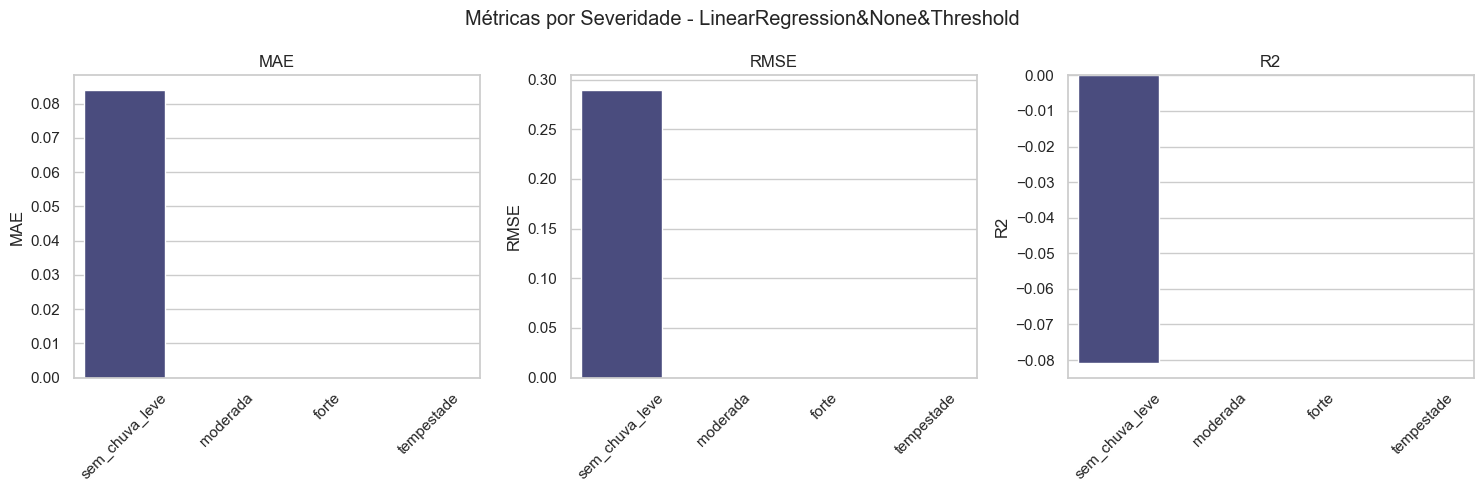

Modelo: LinearRegression&None&Threshold, RMSE: 0.2897, R2: -0.0809

Rodando: Modelo=DecisionTreeRegressor=None Sampling=Threshold
Modelo de regressão (R) treinado.


C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\2361901795.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')
C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\2361901795.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')
C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\2361901795.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')


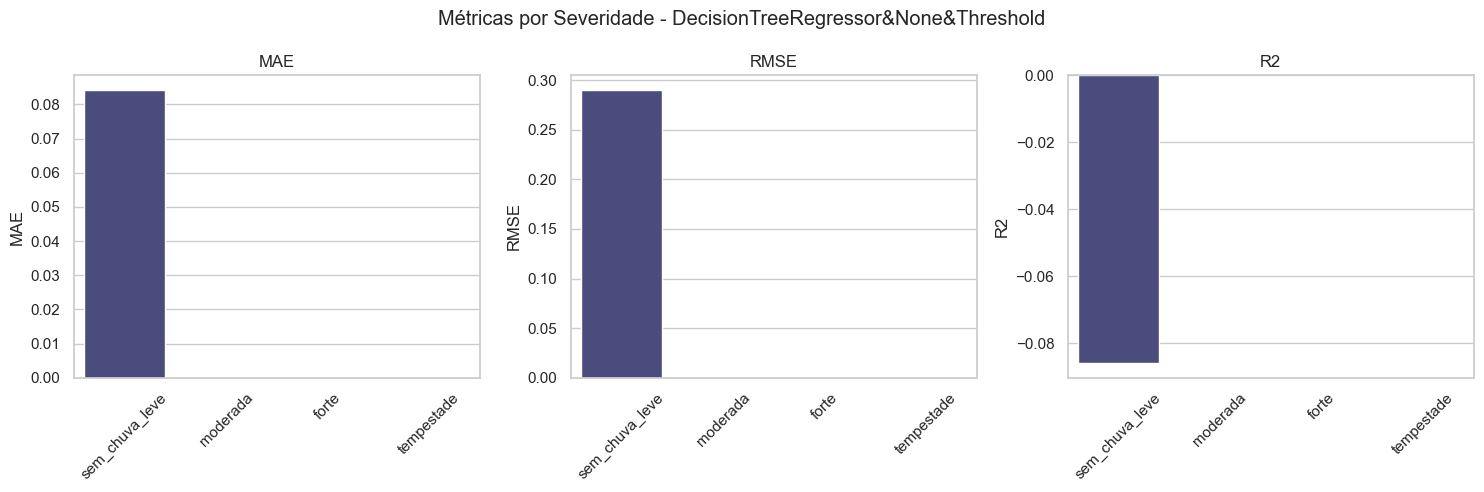

Modelo: DecisionTreeRegressor&None&Threshold, RMSE: 0.2904, R2: -0.0860

Rodando: Modelo=RandomForestRegressor=None Sampling=Threshold
Modelo de regressão (R) treinado.


C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\2361901795.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')
C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\2361901795.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')
C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\2361901795.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')


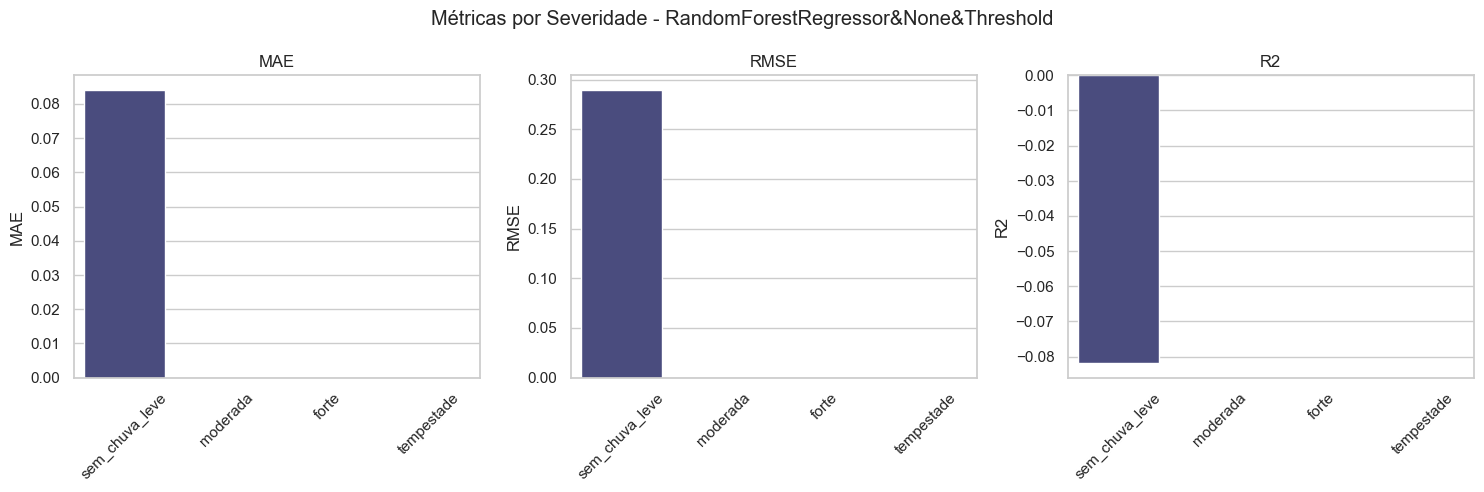

Modelo: RandomForestRegressor&None&Threshold, RMSE: 0.2898, R2: -0.0819


In [63]:

final_results = []
for model_config in model_regression:
    model_class_name = model_config['class_name']
    
    for sampling_config in sampling_configs:
        sampling_name = sampling_config['sampling_name']
        # Se não houver iteração de parâmetros, usamos [None]
        for param_reg in model_config.get('parameter_range', [None]):
            print(f"\nRodando: Modelo={model_class_name}"
                  f"={param_reg} Sampling={sampling_name}")
            
            # Para relatório, definimos um identificador:
            # set_name = f"{model_class_name}&{model_config.get('tuning_parameter','')}&{param_reg}&{sampling_name}"
            set_name = f"{model_class_name}&{param_reg}&{sampling_name}"
            
            # Preparar os parâmetros do modelo de regressão
            model_params_R = model_config['params'].copy()

            
            # Instanciar e treinar o modelo de regressão em (X_train_1, y_train_1)
            model_R = model_config['model_class'](**model_params_R)
            pipeline_R = Pipeline([
                ('preprocessor', preprocessor),
                ('regressor', model_R)
            ])
            pipeline_R.fit(X_train_1, y_train_1)
            print("Modelo de regressão (R) treinado.")
            
            # Obter as predições do regressor para os dados de teste
            # X_test (não processado) será utilizado; o pré-processador fará o escalonamento
            y_pred_reg = pipeline_R.predict(X_test)
            # Obter as predições do classificador C para os mesmos dados de teste
            y_pred_class = pipeline_C.predict(X_test)
            # Combinar os resultados: se o classificador prever 0, a predição final é 0; senão, usa a predição do regressor.
            y_pred_final = np.where(y_pred_class == 0, 0, y_pred_reg)
            
            # Para avaliação, compare y_pred_final com os valores contínuos reais do teste (y_test)
            mse = mean_squared_error(y_test, y_pred_final)
            mae = mean_absolute_error(y_test, y_pred_final)
            rmse = np.sqrt(mse)
            r2   = r2_score(y_test, y_pred_final)
            
            # Criar um relatório de métricas por severidade
            severity_report = report_severity_metrics(y_test, y_pred_final)
            
            final_results.append({
                "Model": set_name,
                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse,
                "R2": r2,
                "Severity_Report": severity_report
            })
            plot_severity_metrics(severity_report, set_name )
            print(f"Modelo: {set_name}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
 

In [64]:
 
# Converter os resultados finais para DataFrame e exibir
df_final_results = pd.DataFrame(final_results)
print("\nResultados finais dos modelos de regressão (modelo híbrido):")
print(df_final_results)

# =============================================================================
# Seleção do melhor modelo (por exemplo, o com menor RMSE)
# =============================================================================
best_model_result = df_final_results.loc[df_final_results['RMSE'].idxmin()]
print("\nMelhor modelo selecionado:")
print(best_model_result)


# results_json_path = os.path.join(os.path.dirname(os.path.realpath(__file__)), 'final_results.json')
# df_final_results.to_json(results_json_path, orient='records', lines=True)

end_time = time.time()
print(f"\nTempo total de execução: {end_time - start_time:.2f} segundos")


Resultados finais dos modelos de regressão (modelo híbrido):
                                  Model       MAE       MSE      RMSE  \
0       LinearRegression&None&Threshold  0.084053  0.083931  0.289708   
1  DecisionTreeRegressor&None&Threshold  0.084325  0.084325  0.290387   
2  RandomForestRegressor&None&Threshold  0.084171  0.084008  0.289841   

         R2                                    Severity_Report  
0 -0.080918  {'sem_chuva_leve': {'count': 9582, 'MAE': 0.08...  
1 -0.085993  {'sem_chuva_leve': {'count': 9582, 'MAE': 0.08...  
2 -0.081910  {'sem_chuva_leve': {'count': 9582, 'MAE': 0.08...  

Melhor modelo selecionado:
Model                                LinearRegression&None&Threshold
MAE                                                         0.084053
MSE                                                         0.083931
RMSE                                                        0.289708
R2                                                         -0.080918
Severity_Rep

# (5) Calibração de modelos

In [85]:
# Start timing
start_time = time.time()

In [86]:

# ===========================
# DATA LOADING AND PREPROCESSING
# ===========================
# Define column names
column_names = ["Education", "Dependents", "Income", "PropertyType", "AssetValue", "Installments", "InstallmentValue", "Phone", "Age", "ResidenceMonths", "DownPayment", "Target"]
categorical_columns = ["Education", "Dependents", "PropertyType", "Phone"]  
numerical_columns = ["Income", "AssetValue", "Installments", "InstallmentValue", "Age", "ResidenceMonths", "DownPayment"]
target_column = "Target"  

# Load training and testing data
try:
    df_train = pd.read_csv('credtrain.txt', sep='\t', header=None)
    df_test = pd.read_csv('credtest.txt', sep='\t', header=None)
except FileNotFoundError:
    base_path = os.path.dirname(os.path.realpath(__file__))
    df_train = pd.read_csv(os.path.join(base_path, 'credtrain.txt'), sep='\t', header=None)
    df_test = pd.read_csv(os.path.join(base_path, 'credtest.txt'), sep='\t', header=None)

df_train.columns = column_names
df_test.columns = column_names


In [87]:
# Separate features and target
X_test, y_test = df_test.drop(target_column, axis=1), df_test[target_column]
X_train, y_train = df_train.drop(target_column, axis=1), df_train[target_column]

# Additional split: training and validation
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, train_size=.5)
df_train_split = pd.DataFrame(X_train_split, columns=column_names[:-1])
df_train_split[target_column] = y_train_split

df_val = pd.DataFrame(X_val, columns=column_names[:-1])
df_val[target_column] = y_val


In [88]:
# Create preprocessor using ColumnTransformer:
# - OneHotEncoder for categorical columns.
# - StandardScaler for numerical columns.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_columns),
        ('num', StandardScaler(), numerical_columns)
    ]
)

# Fit the preprocessor with training data (features only) and apply it to partitions
X_train_split_transformed = preprocessor.fit_transform(X_train_split)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

# Define model configurations; include tuning keys for models that require parameter tuning.
model_configurations = [
    {
        'class_name': "KNeighborsClassifier",
        'model_class': KNeighborsClassifier
    },
    {
        'class_name': "LogisticRegression",
        'model_class': LogisticRegression
    },
    {
        'class_name': "GradientBoostingClassifier",
        'model_class': GradientBoostingClassifier,
    }
]

calibration_methods = [
    {
        'calibration_name': "CalibClassCV_Prefit",
        'calibration_class': CalibratedClassifierCV,
        'params': {'cv': 'prefit'}
    },
    {
        'calibration_name': "CalibClassCV_5Fold",
        'calibration_class': CalibratedClassifierCV,
        'params': {'cv': 5}
    },
    {
        'calibration_name': "CalibClassCV_Prefit_Isotonic",
        'calibration_class': CalibratedClassifierCV,
        'params': {'cv': 'prefit',  'method': 'isotonic'}
    },
    {
        'calibration_name': "CalibClassCV_Prefit_Sigmoid",
        'calibration_class': CalibratedClassifierCV,
        'params': {'cv': 'prefit', 'method': 'sigmoid'}
    },
    {
        'calibration_name': "None",
        'calibration_class': None,
    },
]

Processing model: KNeighborsClassifier
Best threshold (Val) for KNeighborsClassifier with calibration 'CalibClassCV_Prefit': 0.8460 | Young: 0.7156
Best threshold (Test) for KNeighborsClassifier with calibration 'CalibClassCV_Prefit': 0.6318 | Young: 0.7325


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


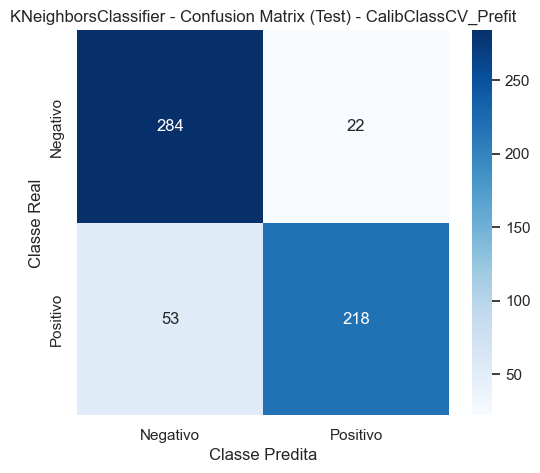

Best threshold (Val) for KNeighborsClassifier with calibration 'CalibClassCV_5Fold': 0.4999 | Young: 0.7059
Best threshold (Test) for KNeighborsClassifier with calibration 'CalibClassCV_5Fold': 0.6042 | Young: 0.7144


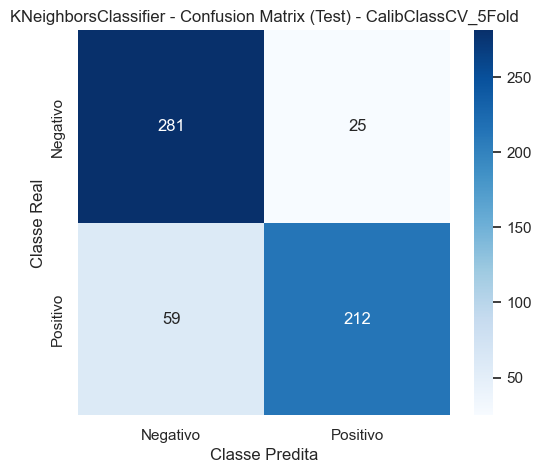

c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Best threshold (Val) for KNeighborsClassifier with calibration 'CalibClassCV_Prefit_Isotonic': 0.8571 | Young: 0.7156
Best threshold (Test) for KNeighborsClassifier with calibration 'CalibClassCV_Prefit_Isotonic': 0.4561 | Young: 0.7325


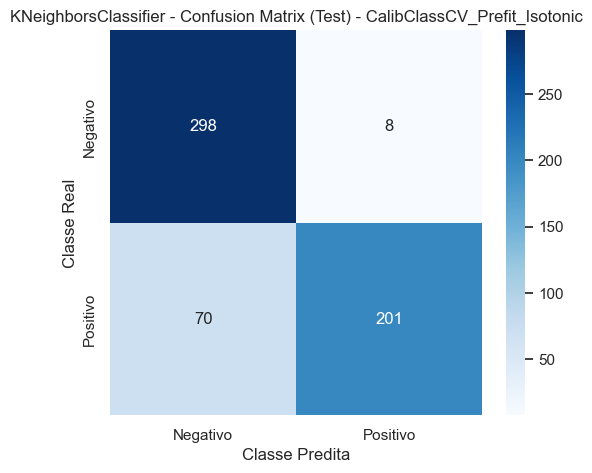

c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Best threshold (Val) for KNeighborsClassifier with calibration 'CalibClassCV_Prefit_Sigmoid': 0.8460 | Young: 0.7156
Best threshold (Test) for KNeighborsClassifier with calibration 'CalibClassCV_Prefit_Sigmoid': 0.6318 | Young: 0.7325


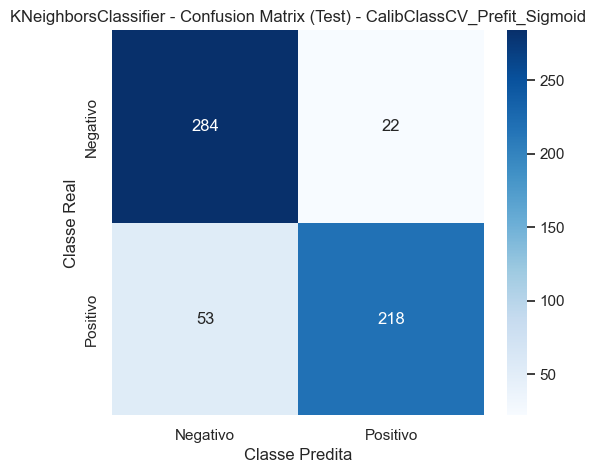

Best threshold (Val) for KNeighborsClassifier with calibration 'None': 0.8000 | Young: 0.7156
Best threshold (Test) for KNeighborsClassifier with calibration 'None': 0.6000 | Young: 0.7325


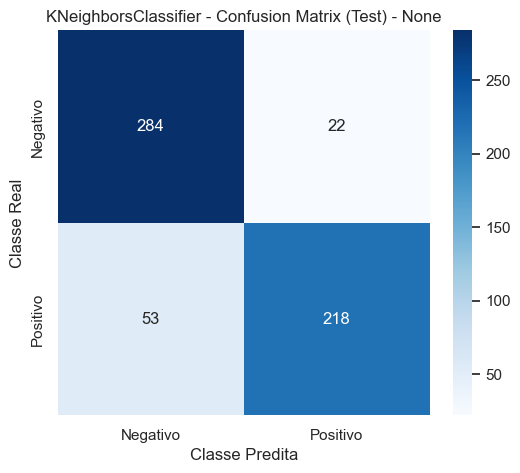

Best calibration for KNeighborsClassifier is: CalibClassCV_Prefit_Isotonic with Brier: 0.1057, ECE: 0.0000


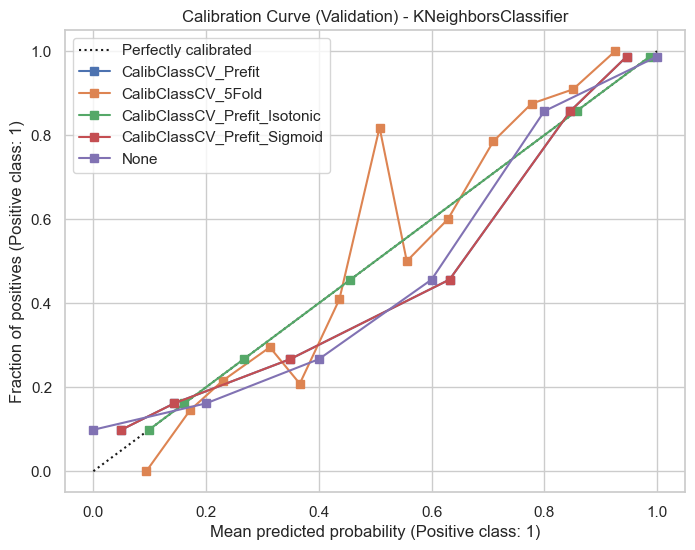

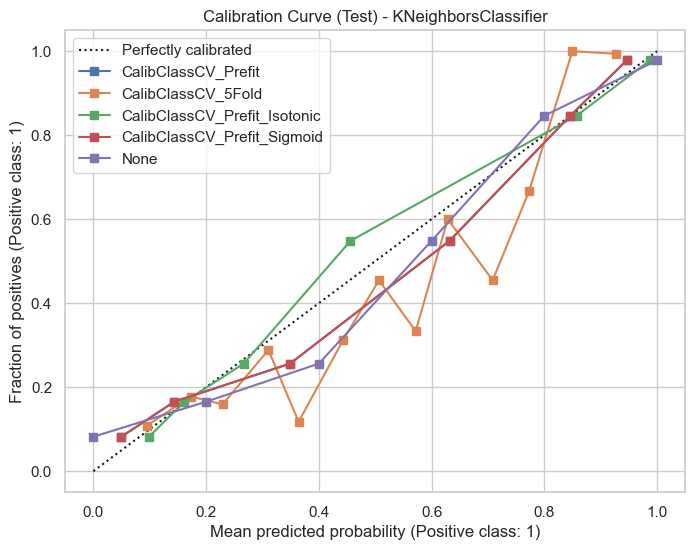

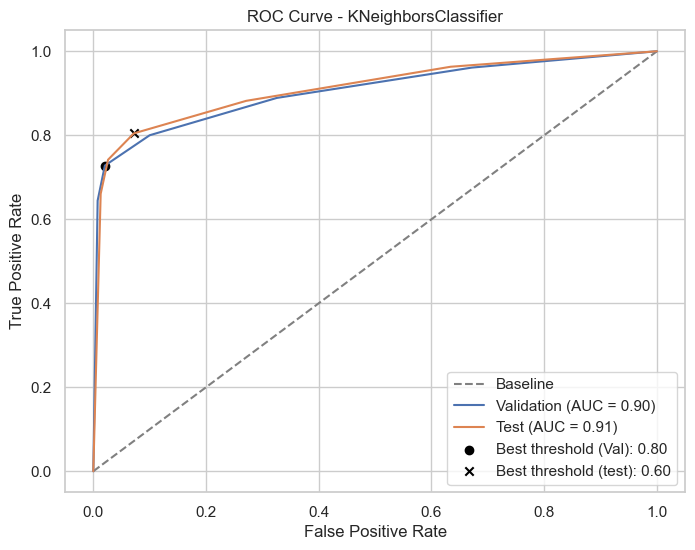

Processing model: LogisticRegression
Best threshold (Val) for LogisticRegression with calibration 'CalibClassCV_Prefit': 0.6262 | Young: 0.7664
Best threshold (Test) for LogisticRegression with calibration 'CalibClassCV_Prefit': 0.5508 | Young: 0.7754


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


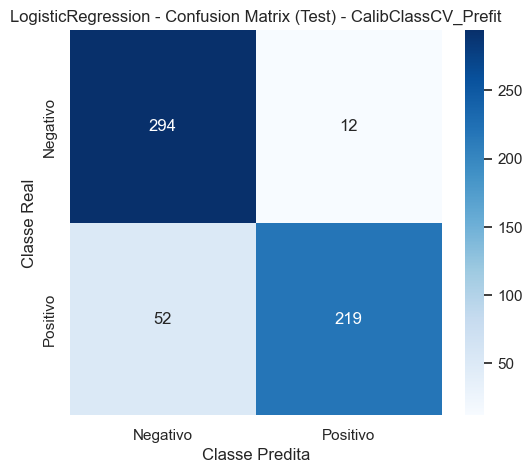

Best threshold (Val) for LogisticRegression with calibration 'CalibClassCV_5Fold': 0.5530 | Young: 0.7734
Best threshold (Test) for LogisticRegression with calibration 'CalibClassCV_5Fold': 0.5409 | Young: 0.7857


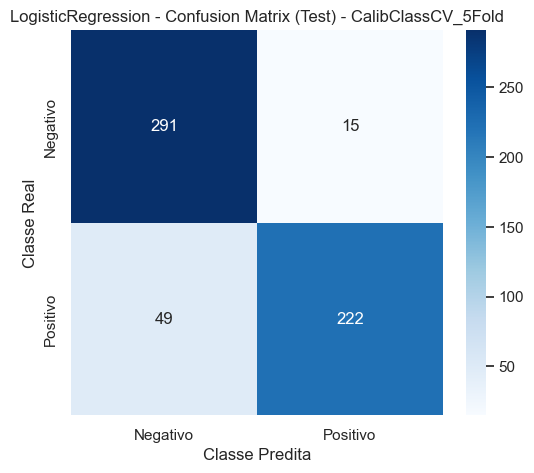

Best threshold (Val) for LogisticRegression with calibration 'CalibClassCV_Prefit_Isotonic': 0.9474 | Young: 0.5871
Best threshold (Test) for LogisticRegression with calibration 'CalibClassCV_Prefit_Isotonic': 0.4444 | Young: 0.7705


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


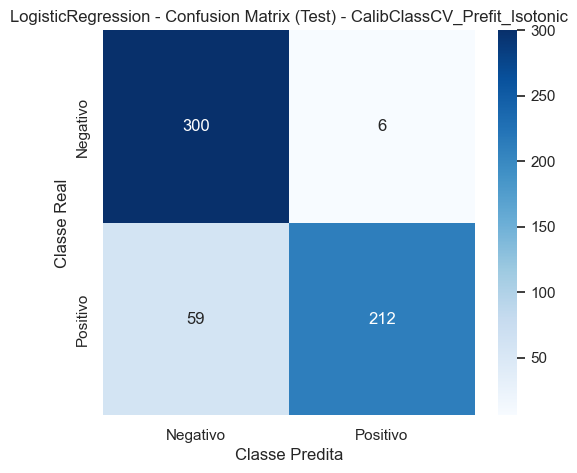

c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Best threshold (Val) for LogisticRegression with calibration 'CalibClassCV_Prefit_Sigmoid': 0.6262 | Young: 0.7664
Best threshold (Test) for LogisticRegression with calibration 'CalibClassCV_Prefit_Sigmoid': 0.5508 | Young: 0.7754


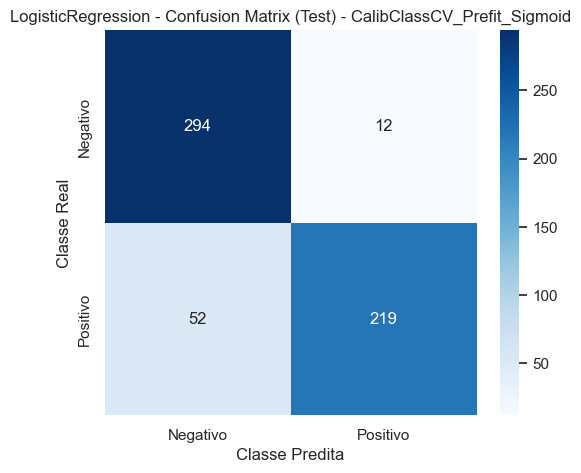

Best threshold (Val) for LogisticRegression with calibration 'None': 0.6372 | Young: 0.7664
Best threshold (Test) for LogisticRegression with calibration 'None': 0.5653 | Young: 0.7754


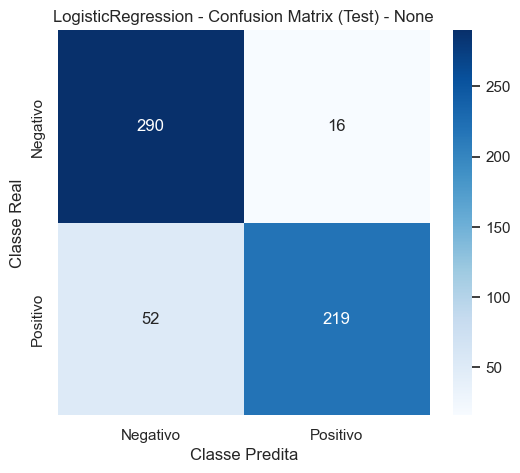

Best calibration for LogisticRegression is: CalibClassCV_Prefit_Isotonic with Brier: 0.0783, ECE: 0.0000


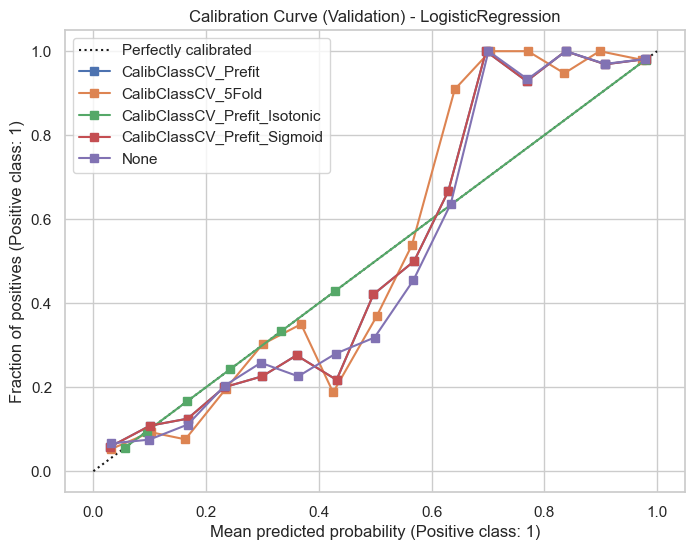

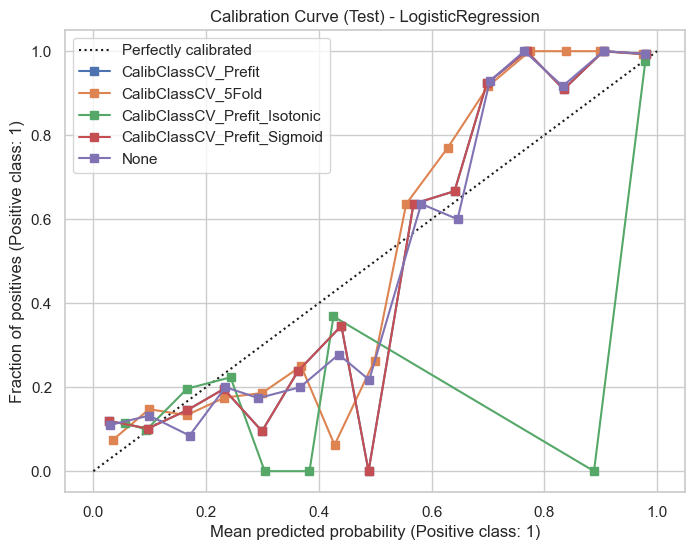

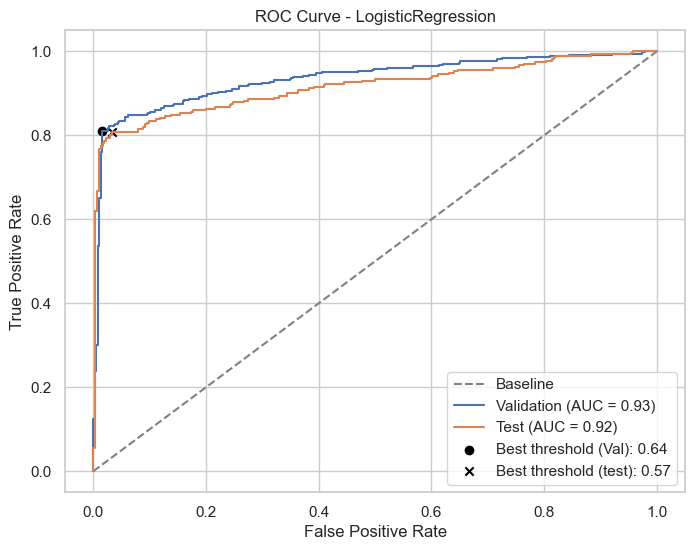

Processing model: GradientBoostingClassifier
Best threshold (Val) for GradientBoostingClassifier with calibration 'CalibClassCV_Prefit': 0.5527 | Young: 0.7865
Best threshold (Test) for GradientBoostingClassifier with calibration 'CalibClassCV_Prefit': 0.5190 | Young: 0.7947


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


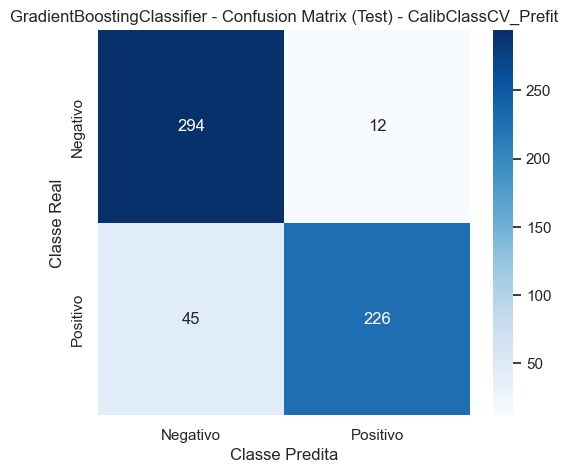

Best threshold (Val) for GradientBoostingClassifier with calibration 'CalibClassCV_5Fold': 0.3307 | Young: 0.7482
Best threshold (Test) for GradientBoostingClassifier with calibration 'CalibClassCV_5Fold': 0.5300 | Young: 0.8008


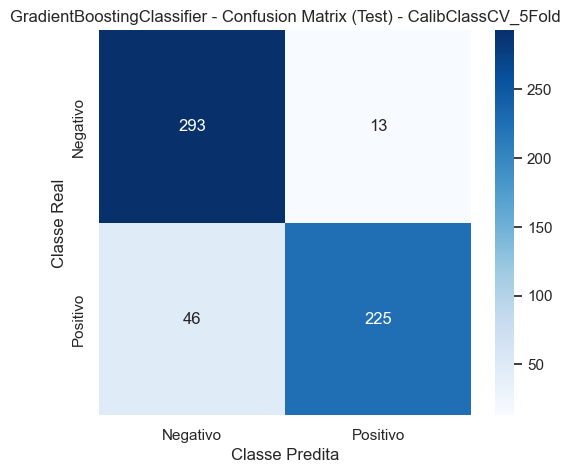

Best threshold (Val) for GradientBoostingClassifier with calibration 'CalibClassCV_Prefit_Isotonic': 0.5714 | Young: 0.7840
Best threshold (Test) for GradientBoostingClassifier with calibration 'CalibClassCV_Prefit_Isotonic': 0.5714 | Young: 0.7906


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


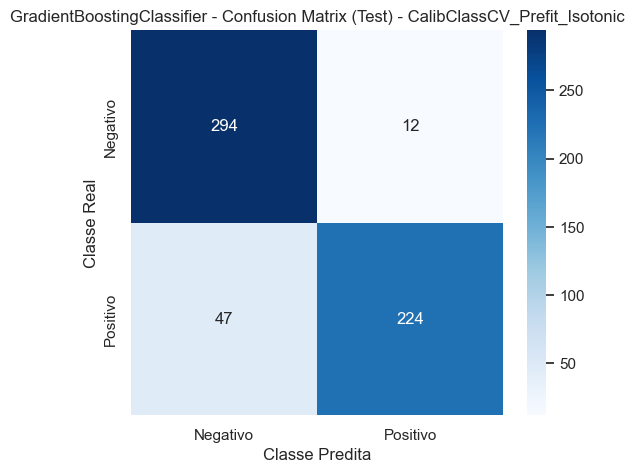

c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Best threshold (Val) for GradientBoostingClassifier with calibration 'CalibClassCV_Prefit_Sigmoid': 0.5527 | Young: 0.7865
Best threshold (Test) for GradientBoostingClassifier with calibration 'CalibClassCV_Prefit_Sigmoid': 0.5190 | Young: 0.7947


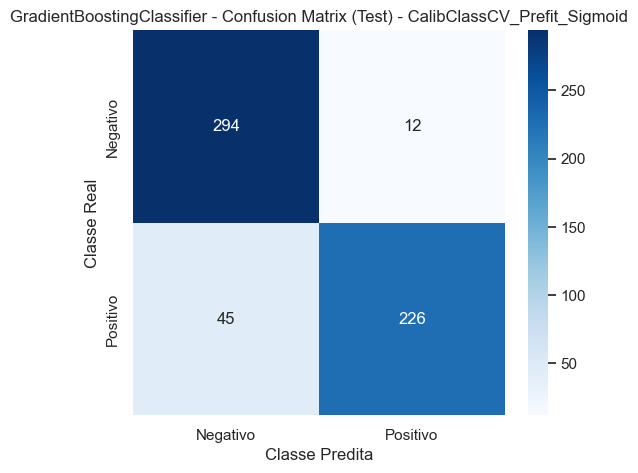

Best threshold (Val) for GradientBoostingClassifier with calibration 'None': 0.5694 | Young: 0.7865
Best threshold (Test) for GradientBoostingClassifier with calibration 'None': 0.5321 | Young: 0.7947


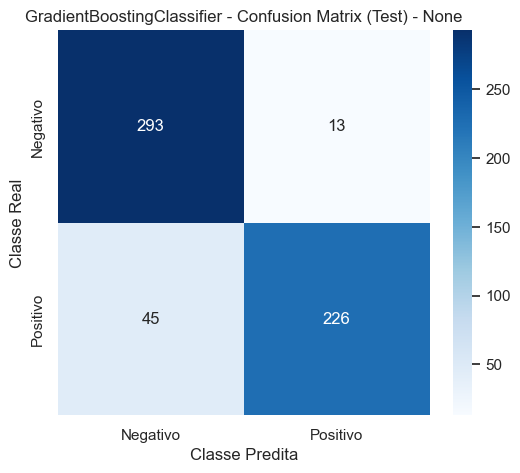

Best calibration for GradientBoostingClassifier is: CalibClassCV_Prefit_Isotonic with Brier: 0.0747, ECE: 0.0000


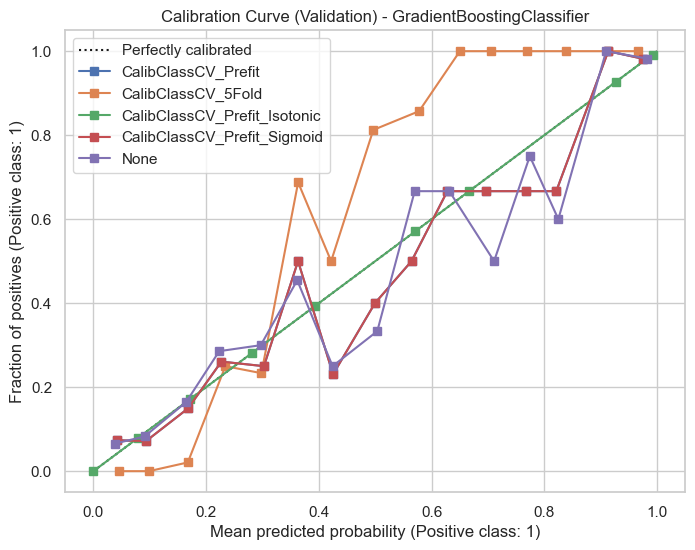

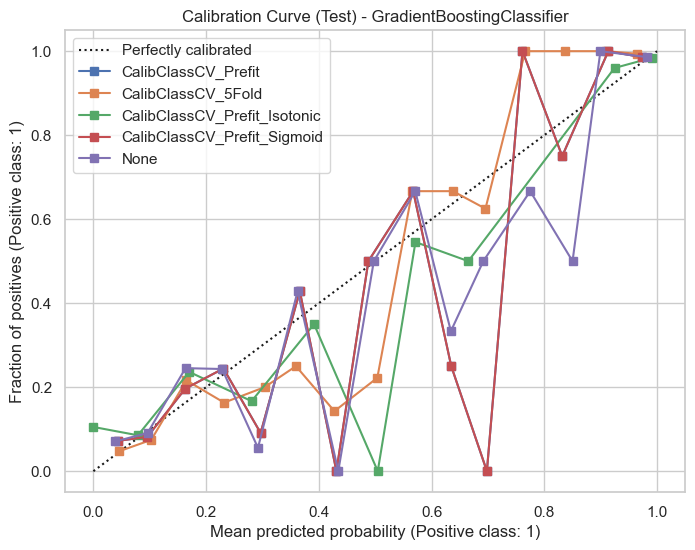

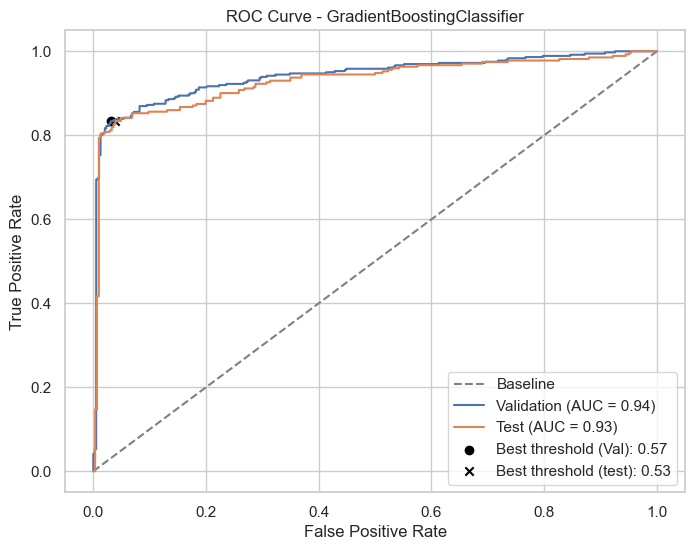

In [89]:
results = []
# Lists to accumulate calibration curves for joint plotting (validation and test)
calibration_curves_val = []
calibration_curves_test = []

# Iterate through all models defined in model_configurations
for config in model_configurations:
    model_class_name = config['class_name']
    print(f"Processing model: {model_class_name}")
    
    # Create classifier pipeline with preprocessor
    clf = config['model_class']()
    pipeline_clf = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    # Train the pipeline using training data (split)
    pipeline_clf.fit(X_train_split, y_train_split)
    
    # List to store calibration results for this model
    model_calibration_results = []
    
    # For each calibration configuration, fit or use the model without calibration
    for calib in calibration_methods:
        calib_name = calib['calibration_name']
        if calib['calibration_class'] is not None:
            # Instantiate the calibrator with the 'estimator' parameter
            calibrator = calib["calibration_class"](estimator=pipeline_clf, **calib["params"])
            # Calibrate using validation data
            calibrator.fit(X_val, y_val)
            used_model = calibrator
        else:
            used_model = pipeline_clf

        # Get predictions and probabilities for validation and test
        y_pred_val   = used_model.predict(X_val)
        y_proba_val  = used_model.predict_proba(X_val)[:, 1]
        y_pred_test  = used_model.predict(X_test)
        y_proba_test = used_model.predict_proba(X_test)[:, 1]
        
        # Calculate ROC curves and ROC AUC
        fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_proba_val)
        roc_auc_val = roc_auc_score(y_val, y_proba_val)
        
        closest_val = np.sqrt(fpr_val**2 + (1 - tpr_val)**2)
        gmeans_val = np.sqrt(tpr_val * (1 - fpr_val))
        young_val = tpr_val + (1 - fpr_val) - 1

        fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_proba_test)
        roc_auc_test = roc_auc_score(y_test, y_proba_test)
        
        closest_test = np.sqrt(fpr_test**2 + (1 - tpr_test)**2)
        gmeans_test = np.sqrt(tpr_test * (1 - fpr_test))
        young_test = tpr_test + (1 - fpr_test) - 1
        
        # Determine the best threshold on the youg
        ix_val = np.argmax(young_val)
        best_threshold_val = thresholds_val[ix_val]
        print(f"Best threshold (Val) for {model_class_name} with calibration '{calib_name}': {best_threshold_val:.4f} | Young: {young_test[ix_val]:.4f}")
        
        ix_test = np.argmax(young_test)
        best_threshold_test = thresholds_test[ix_test]
        print(f"Best threshold (Test) for {model_class_name} with calibration '{calib_name}': {best_threshold_test:.4f} | Young: {young_test[ix_test]:.4f}")
        
        # Plot confusion matrix for the test set (fixed threshold 0.5)
        cm = confusion_matrix(y_test, (y_proba_test >= 0.5).astype(int))
        tn, fp, fn, tp = cm.ravel()
        plot_confusion_matrix_from_values(tp, tn, fp, fn, title=f"{model_class_name} - Confusion Matrix (Test) - {calib_name}")
        
        # Accumulate data (labels and probabilities) for calibration curve plotting
        calibration_curves_val.append((y_val, y_proba_val, calib_name))
        calibration_curves_test.append((y_test, y_proba_test, calib_name))
        
        # Calculate performance metrics on the validation set
        accuracy  = accuracy_score(y_val, y_pred_val)
        precision = precision_score(y_val, y_pred_val, zero_division=0)
        recall    = recall_score(y_val, y_pred_val, zero_division=0)
        f1        = f1_score(y_val, y_pred_val, zero_division=0)
        
        # Calculate calibration metrics
        calibration_metrics = evaluate_calibration(y_val, y_proba_val, n_bins=15)
        
        result_item = {
            'class_name': model_class_name,
            'calibration': calib_name,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc_val': roc_auc_val,
            'roc_auc_test': roc_auc_test,
            'best_threshold': best_threshold_test,
        }
        # Merge calibration metrics into the result dictionary
        result_item.update(calibration_metrics)
        results.append(result_item)
        model_calibration_results.append(result_item)
    
    # Select the best calibration configuration for this model
    best_calibration_for_model = select_best_calibration(model_calibration_results)
    print(f"Best calibration for {model_class_name} is: {best_calibration_for_model['calibration']} with Brier: {best_calibration_for_model['Brier Score']:.4f}, ECE: {best_calibration_for_model['ECE']:.4f}")
    
    # --- Joint plotting of calibration curves for this model ---
    plt.figure(figsize=(8, 6))
    ax_val = plt.gca()
    
    for (y_true_val, y_prob_val, label_cal) in calibration_curves_val:
        disp = CalibrationDisplay.from_predictions(y_true_val, y_prob_val, n_bins=15, ax=ax_val, label=label_cal)
    ax_val.set_title(f"Calibration Curve (Validation) - {model_class_name}")
    ax_val.legend(loc="best")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 6))
    ax_test = plt.gca()
    
    for (y_true_test, y_prob_test, label_cal) in calibration_curves_test:
        disp = CalibrationDisplay.from_predictions(y_true_test, y_prob_test, n_bins=15, ax=ax_test, label=label_cal)
    ax_test.set_title(f"Calibration Curve (Test) - {model_class_name}")
    ax_test.legend(loc="best")
    plt.grid(True)
    plt.show()
    
    # Plot ROC curves for validation and test
    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline')
    plt.plot(fpr_val, tpr_val, label=f"Validation (AUC = {roc_auc_val:.2f})")
    plt.plot(fpr_test, tpr_test, label=f"Test (AUC = {roc_auc_test:.2f})")
    plt.scatter(fpr_val[ix_val], tpr_val[ix_val], marker='o', color='black', label=f"Best threshold (Val): {best_threshold_val:.2f}")
    plt.scatter(fpr_test[ix_test], tpr_test[ix_test], marker='x', color='black', label=f"Best threshold (test): {best_threshold_test:.2f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_class_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # Clear lists for the next model
    calibration_curves_val.clear()
    calibration_curves_test.clear()

In [90]:

# Display overall results in a DataFrame
df_results = pd.DataFrame(results)
print(df_results)

# Select the best overall model based on test ROC AUC
best_model = max(results, key=lambda item: item['roc_auc_test'])
calibration_str = (f"Calibration: {best_model['calibration']}" if best_model['calibration'] != "None" else "No calibration")

print("------------------------------------------------------")
print("Best identified model:")
print(f"Model: {best_model['class_name']} / {calibration_str}")
print(f"Accuracy (Validation): {best_model['accuracy']:.4f}")
print(f"Precision (Validation): {best_model['precision']:.4f}")
print(f"Recall (Validation): {best_model['recall']:.4f}")
print(f"F1 Score (Validation): {best_model['f1']:.4f}")
print(f"ROC AUC (Validation): {best_model['roc_auc_val']:.4f}")
print(f"ROC AUC (Test): {best_model['roc_auc_test']:.4f}")
print(f"Brier Score: {best_model['Brier Score']:.4f}")
print(f"ECE: {best_model['ECE']:.4f}")
print(f"MCE: {best_model['MCE']:.4f}")

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal processing time: {elapsed_time:.2f} seconds")

                    class_name                   calibration  accuracy  \
0         KNeighborsClassifier           CalibClassCV_Prefit  0.852000   
1         KNeighborsClassifier            CalibClassCV_5Fold  0.896000   
2         KNeighborsClassifier  CalibClassCV_Prefit_Isotonic  0.858667   
3         KNeighborsClassifier   CalibClassCV_Prefit_Sigmoid  0.852000   
4         KNeighborsClassifier                          None  0.852000   
5           LogisticRegression           CalibClassCV_Prefit  0.893333   
6           LogisticRegression            CalibClassCV_5Fold  0.896000   
7           LogisticRegression  CalibClassCV_Prefit_Isotonic  0.901333   
8           LogisticRegression   CalibClassCV_Prefit_Sigmoid  0.893333   
9           LogisticRegression                          None  0.893333   
10  GradientBoostingClassifier           CalibClassCV_Prefit  0.902667   
11  GradientBoostingClassifier            CalibClassCV_5Fold  0.937333   
12  GradientBoostingClassifier  CalibC

# (6) Validação cruzada aninhada

In [75]:
start_time = time.time()

In [76]:
# 1. Carrega e pré-processa dados
"""Carrega e pré-processa os dados"""
df_diamonds = df_diamonds

# Engenharia de features: Adiciona volume
df_diamonds['volume'] = df_diamonds['x'] * df_diamonds['y'] * df_diamonds['z']

target_column = 'price'
X = df_diamonds.drop(target_column, axis=1)
y = df_diamonds[target_column]


In [77]:

# 2. Divide dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 3. Configura CV
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)


In [78]:

# 4. Executa Nested CV
# =============================================
# 2. Definição do Pipeline e Espaços de Busca
# =============================================

"""Cria o pré-processador com codificação ordinal"""
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume']
categorical_features = ['cut', 'color', 'clarity']
# Define ordens das categorias
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

preprocessor =  ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), 
            categorical_features)
    ])

model_configs = [
        {
            'name': "KNeighborsRegressor",
            'class': KNeighborsRegressor,
            'params': {
                'model__n_neighbors': randint(3, 20),
                'model__weights': ['uniform', 'distance'],
                'model__metric': ['euclidean', 'manhattan']
            },
            'random_state': False
        },
        {
            'name': "GradientBoostingRegressor",
            'class': GradientBoostingRegressor,
            'params': {
                'model__n_estimators': randint(100, 500),
                'model__learning_rate': uniform(0.01, 0.19),
                'model__max_depth': randint(3, 8),
                'model__subsample': uniform(0.6, 0.4)
            },
            'random_state': True
        }
    ]


In [79]:

results = []

for config in model_configs:
    # Configuração do pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', config['class']())
    ])
    
    # Configuração da busca
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config['params'],
        n_iter=20,
        cv=inner_cv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        random_state=42
    )
    
    # Validação cruzada externa
    cv_scores = cross_val_score(
        search, X, y, 
        cv=outer_cv, 
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    # Armazena resultados
    rmse_scores = np.sqrt(-cv_scores)
    best_model = search.fit(X, y).best_estimator_
    
    results.append({
        'model': config['name'],
        'mean_rmse': rmse_scores.mean(),
        'std_rmse': rmse_scores.std(),
        'best_params': search.best_params_,
        'best_estimator': best_model
    })


KeyboardInterrupt: 

In [ ]:

results_df = pd.DataFrame(results)
# 5. Seleciona e avalia o melhor modelo
best_model_info = results_df.loc[results_df['mean_rmse'].idxmin()]
best_model = best_model_info['best_estimator']


In [ ]:

# 6. Avaliação final no teste
y_pred = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

# 7. Feature Importance
feature_names = (X_train.columns.tolist())
if 'GradientBoosting' in best_model_info['model']:
    importances = best_model.named_steps['model'].feature_importances_
else:
    importances = None


In [ ]:

# 8. Gera visualizações
model_evaluation(
    best_model_info['model'], 
    y_test, y_pred,
    feature_importances=importances
)

print(f"\nMelhor modelo: {best_model_info['model']}")
print(f"RMSE no teste: {test_rmse:.2f}")
print(f"R² no teste: {test_r2:.2f}")
print(f"Tempo total: {time.time()-start_time:.2f}s")